In [1]:
from EXPERIMENT_HYPER_EMPIRICAL import *
from _FigureJiazeHelper import *
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse, Circle
import matplotlib.colors as colors
from scipy.sparse.linalg import eigs, eigsh
from scipy.linalg import eig
from scipy.sparse import diags, csc_matrix
import hypergraphx as hgx
from _HyperCommunityDetection import *
from hypergraphx.viz import draw_communities
from hypergraphx.viz.draw_hypergraph import draw_hypergraph
import warnings
import pandas as pd
from matplotlib.ticker import MaxNLocator
warnings.filterwarnings('ignore', category=FutureWarning)

%load_ext autoreload
%autoreload 2

In [2]:
# Matplotlib settings

# plt.style.use('seaborn-whitegrid')
plt.rc('figure', figsize=(8, 5))
plt.rc('font', size=16)
plt.rc('font', family='sans-serif')
plt.rcParams['font.sans-serif'] = 'verdana'
plt.rcParams['lines.linewidth'] = 4
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.edgecolor'] = basic_line_color
plt.rcParams['xtick.color'] = basic_line_color
plt.rcParams['ytick.color'] = basic_line_color
plt.rcParams['axes.labelsize'] = 'large'
plt.rcParams['lines.markersize'] = 12

%config InlineBackend.figure_format = 'retina'

# Connect strength
Node community incidence matrix : $\Psi\in\left\{0,1\right\}^{n\times q}$.

Node hyperedge incidence matrix : $H\in\left\{0,1\right\}^{n\times m}$.

Communtiy hyperedge matrix: $\Psi^TH$ dimension $q\times m$, the number of nodes of hyperedge in community.

$\mathrm{nonzero}(\Psi^TH)$, at least 1 nodes of hyperedges exist in community.

$\mathrm{nonzero}(\Psi^TH)\mathrm{nonzero}(H^T\Psi)$ , $q\times q$: how many hyperedges related with two communities or 1 communities. 

In [3]:
def connect_strength_community(H, partition_vec, num_group, consider_k=None, version=2):
    num_community = num_group
    num_nodes = np.size(partition_vec)
    Node_Community_Incidence = np.zeros((num_nodes, num_community))
    for i in range(num_nodes):
        ci = partition_vec[i]
        Node_Community_Incidence[i, ci] = 1
    if consider_k is not None:
        edge_order = H.sum(axis=0).flatten()
        edge_index = np.where(edge_order == consider_k)[0]
        H = H[:, edge_index]
    if version == 1:
        Connect_Strength = np.transpose(Node_Community_Incidence) @ H
        Connect_Strength = Connect_Strength @ H.transpose()
        Connect_Strength = Connect_Strength @ Node_Community_Incidence
    if version == 0:
        Community_Paper_Incidence = np.transpose(Node_Community_Incidence) @ H  # (c, j) the number of nodes of hyperedge j in community c
        Connect_Strength = ((Community_Paper_Incidence) !=0).astype(int)
        Connect_Strength = Connect_Strength @ ((np.transpose(Community_Paper_Incidence)!=0).astype(int))  # (c, c') the number of hyperedges related with community c and c' for c!=c'
    if version == 2:
        Community_Paper_Incidence = np.transpose(Node_Community_Incidence) @ H  # (c, j) the number of nodes of hyperedge j in community c
        Connect_Strength = ((Community_Paper_Incidence) !=0).astype(int)
        Connect_Strength = Connect_Strength @ ((np.transpose(Community_Paper_Incidence)!=0).astype(int))
        author_counts = H.sum(axis=0)  # the number of nodes for hyperedge
        for ci in range(num_community):
            # print(np.sum(((Community_Paper_Incidence[ci, :] - author_counts)==0).astype(int)))
            Connect_Strength[ci, ci] = np.sum(((Community_Paper_Incidence[ci, :] - author_counts) == 0).astype(int))  # the number of papers with all authors in community ci
    print(type(Connect_Strength), np.shape(Connect_Strength))
    """
    Connect_Strength is a (num_community, num_community) matrix, 
    where Connect_Strength[c, c'] is the number of hedges with some nodes in community c and some nodes in c' for c!=c',
    and Connect_Strength[c, c] is the number of hedges with all nodes in community c.
    """
    # print(Connect_Strength)  
    return Connect_Strength

In [4]:
def show_matrix(matrix, ax, ticks=None):
    im = ax.matshow(matrix)
    x_size = np.shape(matrix)[1]
    y_size = np.shape(matrix)[0]
    for i in range(y_size):
        for j in range(x_size):
            c = matrix[i,j]
            plt.gca().text(j, i, str(int(c)), va='center', ha='center', fontsize=12)
    if ticks is not None:
        ax.set_xticks(list(range(x_size)), ticks, size=6)
        ax.set_yticks(list(range(y_size)), ticks, size=6)
    else:
        ax.set_xticks(list(range(x_size)), list(range(x_size)), size=6)
        ax.set_yticks(list(range(y_size)), list(range(y_size)), size=6)

In [5]:
def PartitionMetaCM(partition, meta):
    partition_num = np.size(np.unique(partition))
    meta_num = np.size(np.unique(meta))
    cm = np.zeros((partition_num, meta_num))
    uniquePartition = np.unique(partition)
    uniqueMeta = np.unique(meta)
    for iP in uniquePartition:
        trueIndex = np.where(partition == iP)[0]
        for iM in uniqueMeta:
            i = np.where(uniquePartition == iP)
            j = np.where(uniqueMeta == iM)
            # print(meta, trueIndex)
            cm[i, j] = np.size(np.where(meta[trueIndex]==iM))
    df = pandas.DataFrame(cm, uniquePartition, uniqueMeta)
    return cm, df

In [6]:
def reorder_partition(partition, meta, uniqueMeta=None):
    cm, cm_df = PartitionMetaCM(partition, meta)
    uniquePartition = np.unique(partition)
    uniqueMeta = np.unique(meta) if uniqueMeta is None else uniqueMeta
    partition_score = np.zeros(np.size(uniquePartition))
    for i in range(np.size(uniquePartition)):
        morelikely_j = np.argmax(cm[i, :])
        partition_score[i] = morelikely_j
        # for j in range(np.size(uniqueMeta)):
        #     partition_score[i] += (j+1) * cm[j, i]
    sort_index = np.argsort(partition_score)
    partition_map = dict()
    for i in range(np.size(sort_index)):
        partition_map[sort_index[i]] = i
    reorder_partition = np.zeros(np.size(partition))
    for i in range(np.size(partition)):
        reorder_partition[i] = partition_map[partition[i]]
    return reorder_partition, partition_score[sort_index]

## highschool

In [7]:
name = 'highschool'
ehg = EmpiricalHyperGraph(name)
givenNumGroup = 9
only_assortative = True
edge_order, edge_count = np.unique(ehg.H.sum(axis=0).flatten(), return_counts=True)
order_count = dict(zip(edge_order, edge_count))
print(order_count)
partition_path = f'./result/hyperEmpirical/{name}_BHPartition' \
                f'{f"_given{givenNumGroup}Groups" if givenNumGroup is not None else ""}' \
                f'{f"_assort" if only_assortative else ""}.pkl'
with open(partition_path, 'rb') as fr:
    high_BHpartition = pickle.load(fr)

high_meta = []
with open('./net_data/contact-high-school/highschool_data.pkl', 'rb') as fr:
    _data = pickle.load(fr)
    for i in range(_data['n']):
        high_meta.append(_data['meta'][i])
unique_highmeta = np.unique(high_meta)
meta_name_map = {m:np.where(unique_highmeta==m)[0][0] for m in unique_highmeta}
high_meta = [meta_name_map[m] for m in high_meta]
high_meta = np.array(high_meta)
# print(meta_name_map, unique_highmeta)

Construct highschool hypergraph with 327 nodes, 7818 hyperedges and all possible k is [3, 4, 2, 5].
{2: 5498, 3: 2091, 4: 222, 5: 7}


In [8]:
# reorder partition incidence matrix
high_BHpartition, _ = reorder_partition(high_BHpartition, np.array([unique_highmeta[m] for m in high_meta]), uniqueMeta=unique_highmeta)
print(f"To align well with class label: {unique_highmeta}\n Reorder the hyper BH partition!")

To align well with class label: ['2BIO1' '2BIO2' '2BIO3' 'MP' 'MP*1' 'MP*2' 'PC' 'PC*' 'PSI*']
 Reorder the hyper BH partition!


In [9]:
high_BHpartition = high_BHpartition.astype(int)

D:\BackProgram\Anaconda\envs\network\Lib\site-packages\matplotlib_inline\config.py:68: DeprecationWarning: InlineBackend._figure_format_changed is deprecated in traitlets 4.1: use @observe and @unobserve instead.
  def _figure_format_changed(self, name, old, new):


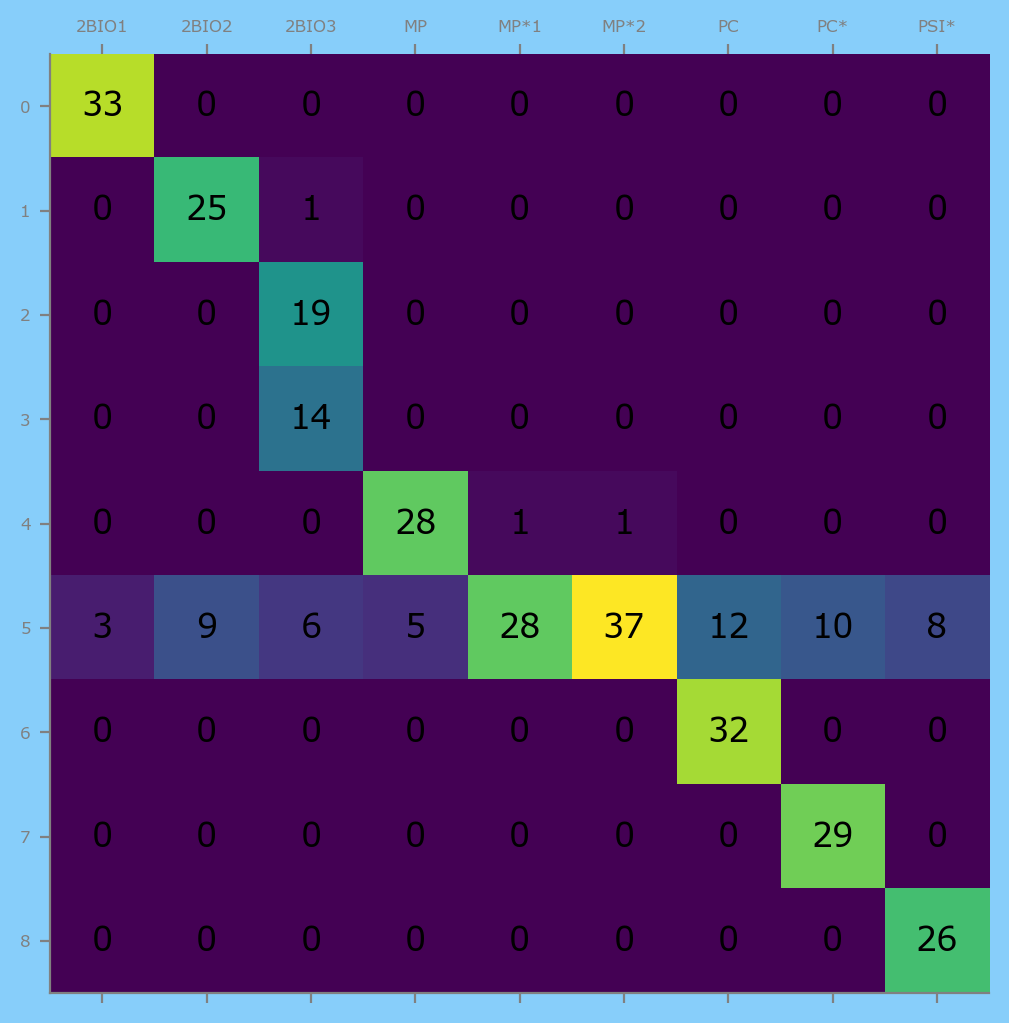

In [10]:
cm, df = PartitionMetaCM(high_BHpartition, high_meta)
fig, ax = plt.subplots(figsize=(5, 5), facecolor='lightskyblue', layout='constrained')
show_matrix(cm, ax=ax)
ax.set_xticks(list(range(9)), unique_highmeta, size=6)

<class 'numpy.ndarray'> (9, 9)
<class 'numpy.ndarray'> (9, 9)
<class 'numpy.ndarray'> (9, 9)
<class 'numpy.ndarray'> (9, 9)
<class 'numpy.ndarray'> (9, 9)
<class 'numpy.ndarray'> (9, 9)
<class 'numpy.ndarray'> (9, 9)
<class 'numpy.ndarray'> (9, 9)
<class 'numpy.ndarray'> (9, 9)
<class 'numpy.ndarray'> (9, 9)


Text(0.5, 1.0, 'highschool projected network')

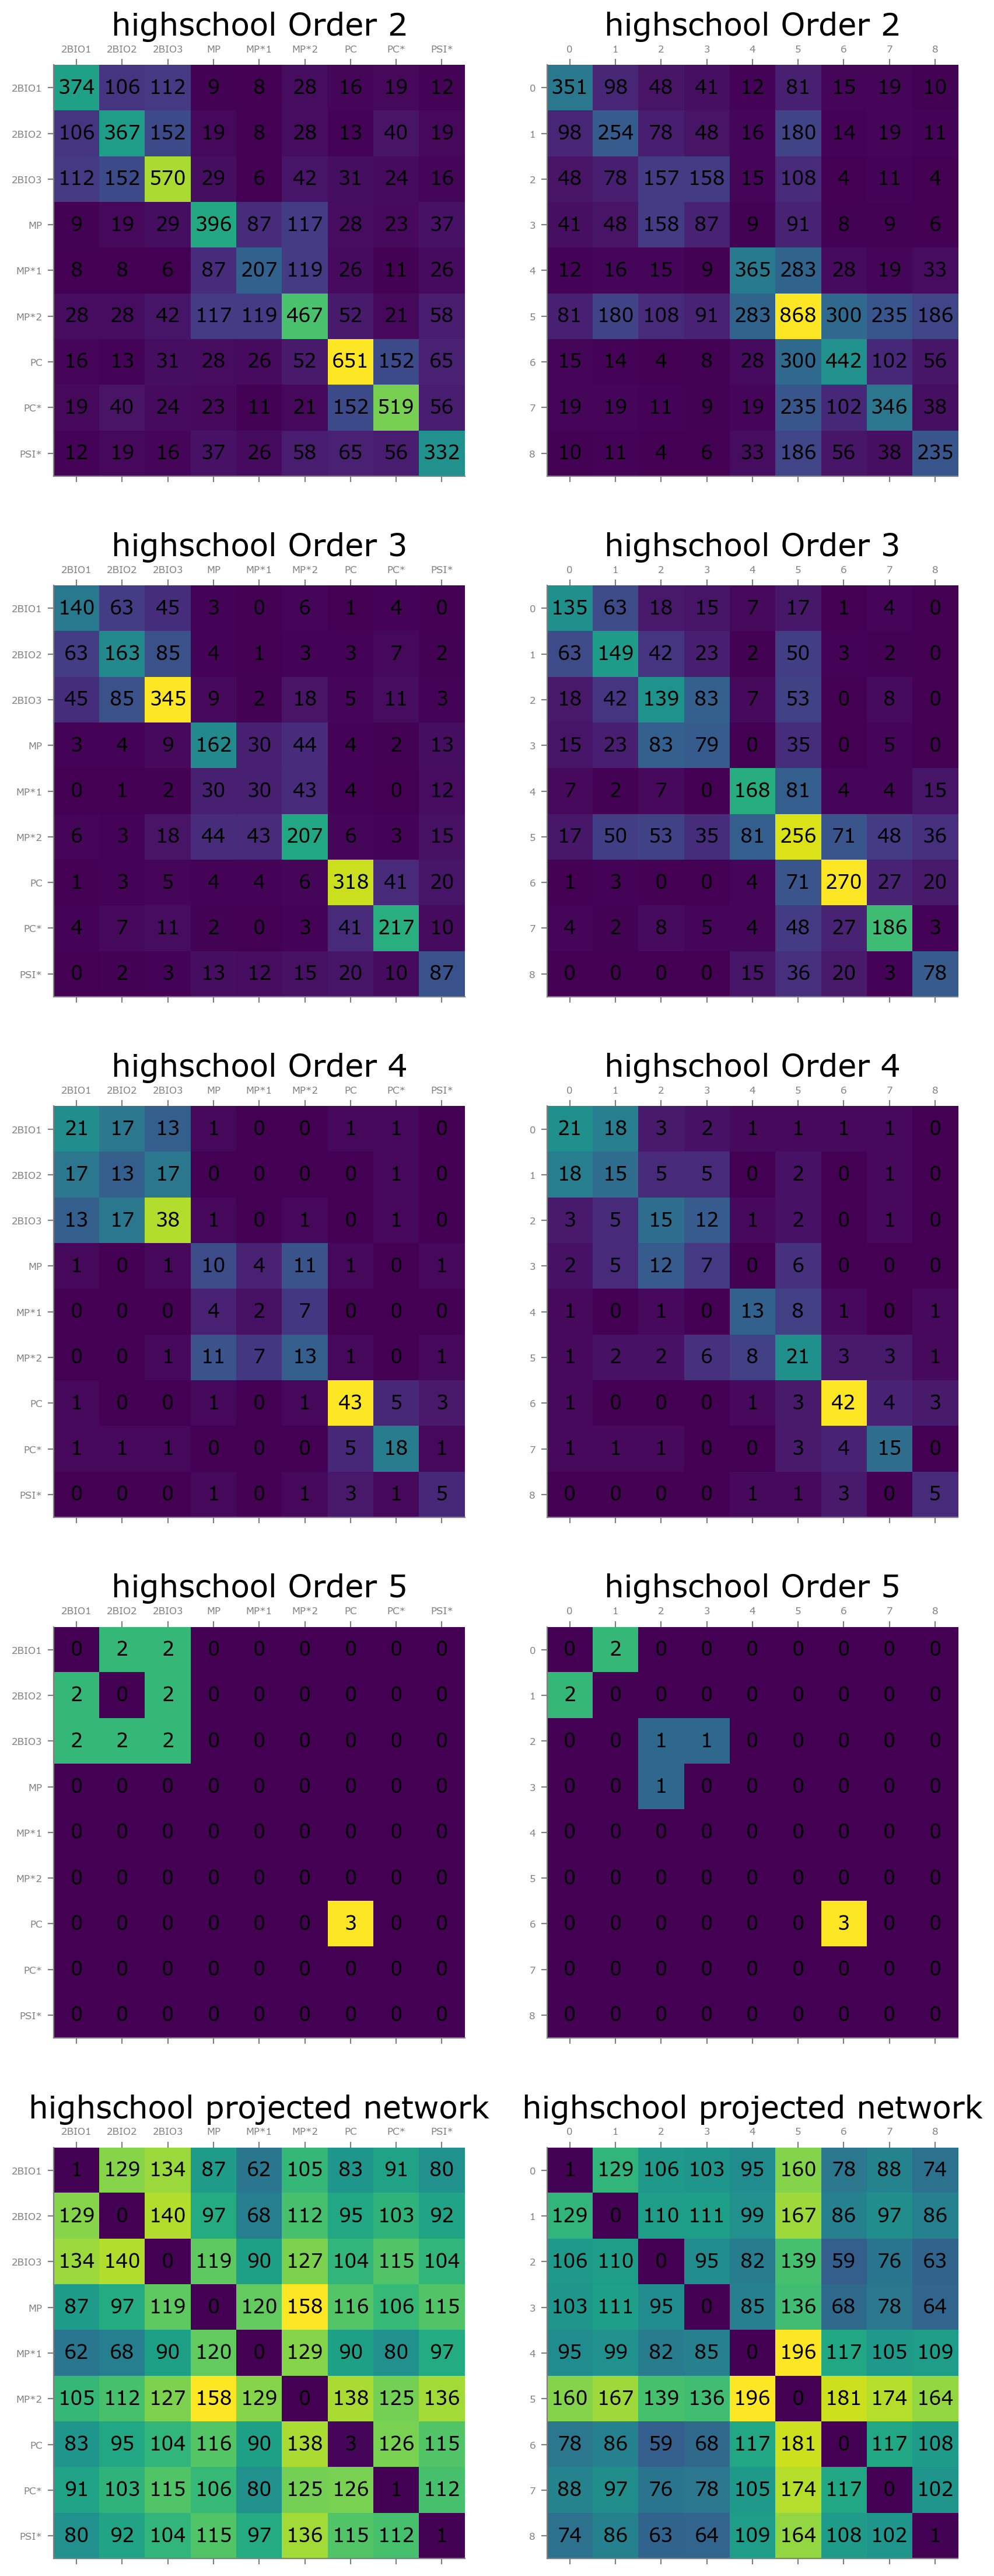

In [11]:
fig = plt.figure(figsize=(10, 28))
widths = [5, 5]
heights = [5, 5, 5, 5, 5]
spec5 = fig.add_gridspec(ncols=2, nrows=5, width_ratios=widths, height_ratios=heights)

row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
consider_k = 2
connect_strength = connect_strength_community(H=ehg.H, partition_vec=high_meta, num_group=givenNumGroup, consider_k=consider_k)
show_matrix(connect_strength, ax, ticks=[unique_highmeta[i] for i in range(9)])
plt.title(f"{name} Order {consider_k}")
col = 1
ax = fig.add_subplot(spec5[row, col])
connect_strength = connect_strength_community(H=ehg.H, partition_vec=high_BHpartition, num_group=givenNumGroup, consider_k=consider_k)
show_matrix(connect_strength, ax)
plt.title(f"{name} Order {consider_k}")

row = 1
col = 0
ax = fig.add_subplot(spec5[row, col])
consider_k = 3
connect_strength = connect_strength_community(H=ehg.H, partition_vec=high_meta, num_group=givenNumGroup, consider_k=consider_k)
show_matrix(connect_strength, ax, ticks=[unique_highmeta[i] for i in range(9)])
plt.title(f"{name} Order {consider_k}")
col = 1
ax = fig.add_subplot(spec5[row, col])
connect_strength = connect_strength_community(H=ehg.H, partition_vec=high_BHpartition, num_group=givenNumGroup, consider_k=consider_k)
show_matrix(connect_strength, ax)
plt.title(f"{name} Order {consider_k}")

row = 2
col = 0
ax = fig.add_subplot(spec5[row, col])
consider_k = 4
connect_strength = connect_strength_community(H=ehg.H, partition_vec=high_meta, num_group=givenNumGroup, consider_k=consider_k)
show_matrix(connect_strength, ax, ticks=[unique_highmeta[i] for i in range(9)])
plt.title(f"{name} Order {consider_k}")
col = 1
ax = fig.add_subplot(spec5[row, col])
connect_strength = connect_strength_community(H=ehg.H, partition_vec=high_BHpartition, num_group=givenNumGroup, consider_k=consider_k)
show_matrix(connect_strength, ax)
plt.title(f"{name} Order {consider_k}")

row = 3
col = 0
ax = fig.add_subplot(spec5[row, col])
consider_k = 5
connect_strength = connect_strength_community(H=ehg.H, partition_vec=high_meta, num_group=givenNumGroup, consider_k=consider_k)
show_matrix(connect_strength, ax, ticks=[unique_highmeta[i] for i in range(9)])
plt.title(f"{name} Order {consider_k}")
col = 1
ax = fig.add_subplot(spec5[row, col])
connect_strength = connect_strength_community(H=ehg.H, partition_vec=high_BHpartition, num_group=givenNumGroup, consider_k=consider_k)
show_matrix(connect_strength, ax)
plt.title(f"{name} Order {consider_k}")

row = 4
col = 0
ax = fig.add_subplot(spec5[row, col])
consider_k = None
projection_H = ehg.H@np.transpose(ehg.H)
projection_H = (projection_H!=0).astype(int)
# print(projection_H)
projection_H = projection_H - diags(projection_H.diagonal())
connect_strength = connect_strength_community(H=projection_H, partition_vec=high_meta, num_group=givenNumGroup, consider_k=consider_k)
show_matrix(connect_strength, ax, ticks=[unique_highmeta[i] for i in range(9)])
plt.title(f"{name} projected network")
col = 1
ax = fig.add_subplot(spec5[row, col])
connect_strength = connect_strength_community(H=projection_H, partition_vec=high_BHpartition, num_group=givenNumGroup, consider_k=consider_k)
show_matrix(connect_strength, ax)
plt.title(f"{name} projected network")

# save_path = f"./_Figure/Hyper/CompareHighPrimary/" + f"FigureHighSchool_NumOfHyperedgesBetweenGroup.pdf"
# plt.tight_layout()
# plt.savefig(save_path, dpi=600)

## primary 

In [19]:
name = "primary"
ehg = EmpiricalHyperGraph(name)
edge_order, edge_count = np.unique(ehg.H.sum(axis=0).flatten(), return_counts=True)
order_count = dict(zip(edge_order, edge_count))
print(order_count)
# partition detected by BH
givenNumGroup = 10
only_assortative = False
partition_path = f'./result/hyperEmpirical/{name}_BHPartition' \
                f'{f"_given{givenNumGroup}Groups" if givenNumGroup is not None else ""}' \
                f'{f"_assort" if only_assortative else ""}.pkl'
with open(partition_path, 'rb') as fr:
    primary_BHpartition = pickle.load(fr)

primary_meta = []
with open('./net_data/contact-primary-school/primary_data.pkl', 'rb') as fr:
    _data = pickle.load(fr)
    for i in range(_data['n']):
        primary_meta.append(_data['meta'][i])
# primary_meta = [np.where(np.unique(primary_meta)==m)[0][0] for m in primary_meta]
unique_primarymeta = np.unique(primary_meta)
meta_name_map = {m:np.where(unique_primarymeta==m)[0][0] for m in unique_primarymeta}
primary_meta = [meta_name_map[m] for m in primary_meta]
primary_meta = np.array(primary_meta)

Construct primary hypergraph with 242 nodes, 12704 hyperedges and all possible k is [2, 3, 4, 5].
{2: 7748, 3: 4600, 4: 347, 5: 9}


In [20]:
# reorder partition incidence matrix
primary_BHpartition, _ = reorder_partition(primary_BHpartition, np.array([unique_primarymeta[m] for m in primary_meta]), uniqueMeta=unique_primarymeta)
print(f"To align well with class label: {unique_primarymeta}\n Reorder the hyper BH partition!")
primary_BHpartition = primary_BHpartition.astype(int)

To align well with class label: ['1A' '1B' '2A' '2B' '3A' '3B' '4A' '4B' '5A' '5B' 'Teachers']
 Reorder the hyper BH partition!


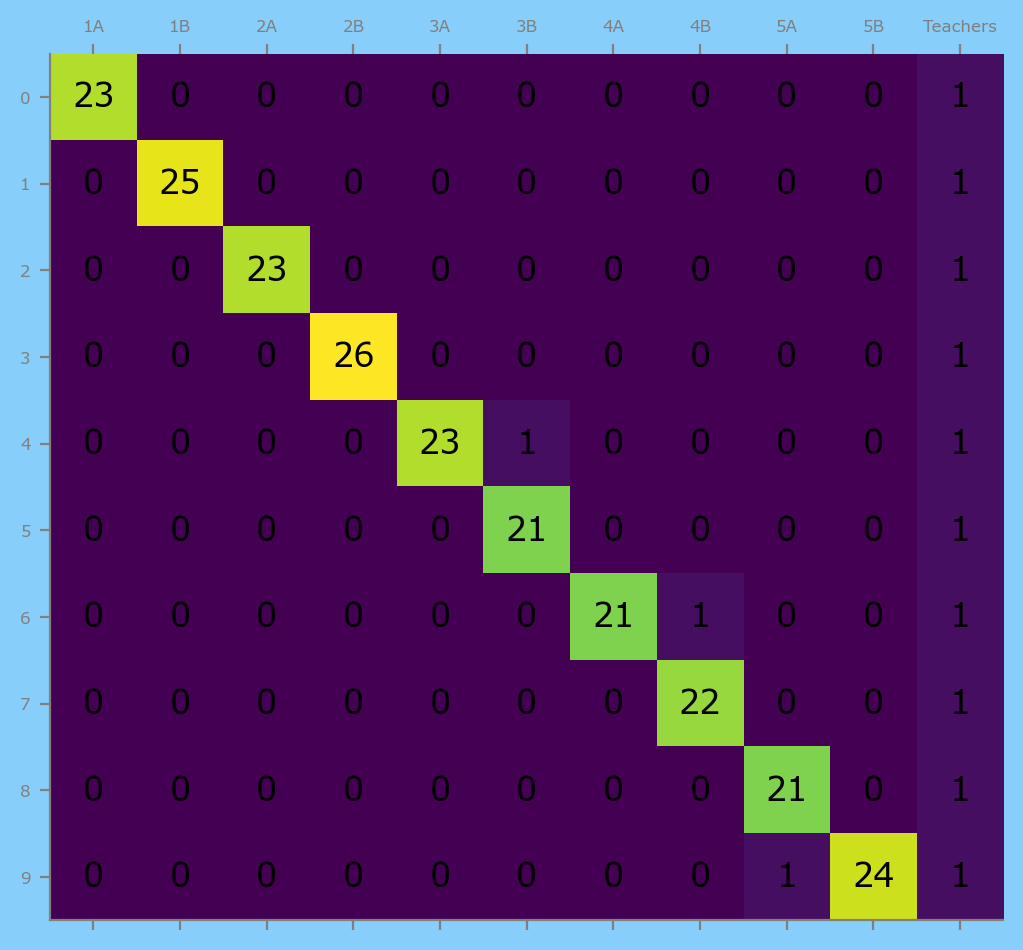

In [31]:
cm, df = PartitionMetaCM(primary_BHpartition, primary_meta)
fig, ax = plt.subplots(figsize=(5, 5), facecolor='lightskyblue', layout='constrained')
show_matrix(cm, ax=ax)
ax.set_xticks(list(range(11)), unique_primarymeta, size=6)

<class 'numpy.ndarray'> (11, 11)
<class 'numpy.ndarray'> (10, 10)
<class 'numpy.ndarray'> (11, 11)
<class 'numpy.ndarray'> (10, 10)
<class 'numpy.ndarray'> (11, 11)
<class 'numpy.ndarray'> (10, 10)
<class 'numpy.ndarray'> (11, 11)
<class 'numpy.ndarray'> (10, 10)
<class 'numpy.ndarray'> (11, 11)
<class 'numpy.ndarray'> (10, 10)


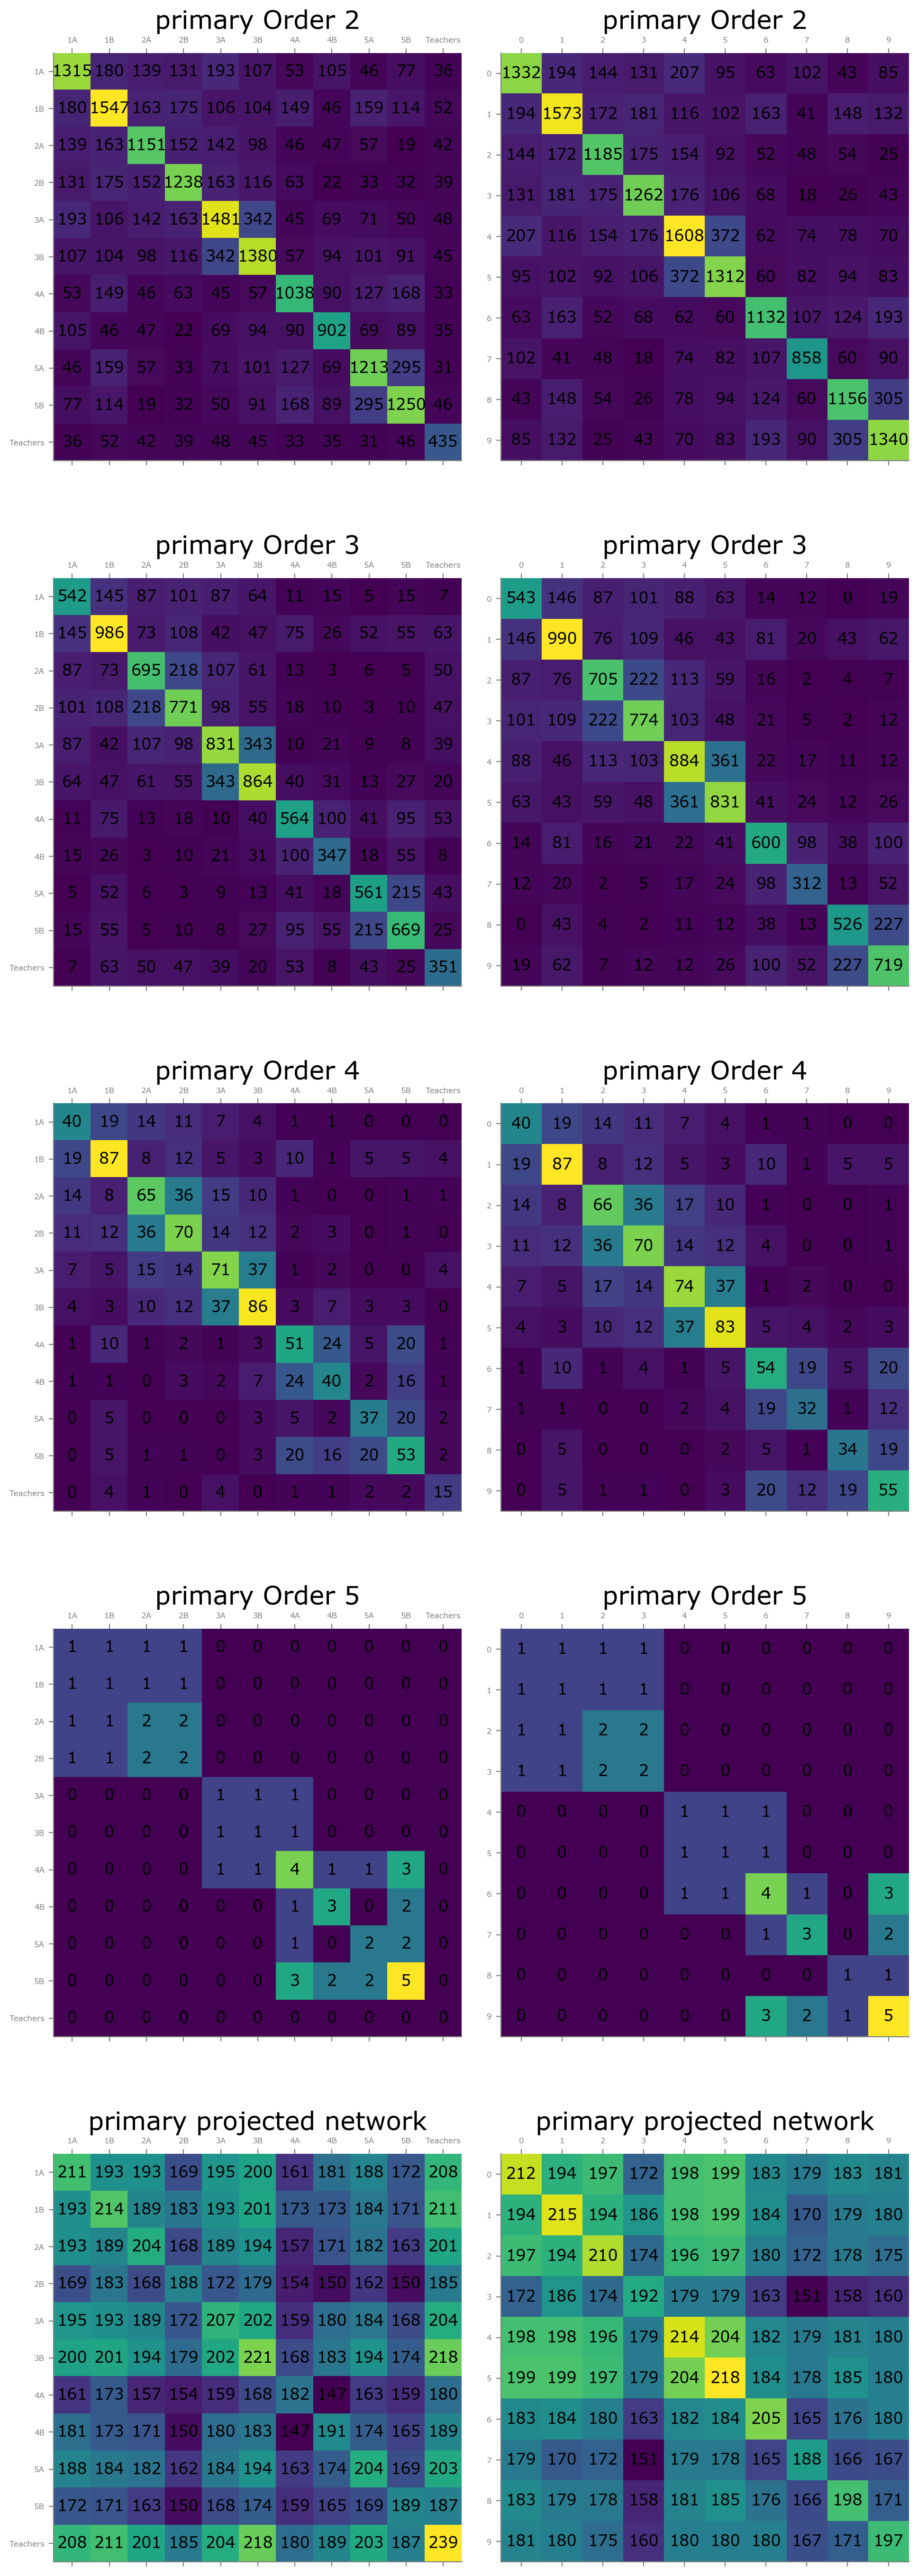

In [36]:
fig = plt.figure(figsize=(10, 28))
widths = [5, 5]
heights = [5, 5, 5, 5, 5]
spec5 = fig.add_gridspec(ncols=2, nrows=5, width_ratios=widths, height_ratios=heights)

num_primary_meta = 11

row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
consider_k = 2
connect_strength = connect_strength_community(H=ehg.H, partition_vec=primary_meta, num_group=num_primary_meta, consider_k=consider_k)
show_matrix(connect_strength, ax, ticks=[unique_primarymeta[i] for i in range(num_primary_meta)])
plt.title(f"{name} Order {consider_k}")
col = 1
ax = fig.add_subplot(spec5[row, col])
connect_strength = connect_strength_community(H=ehg.H, partition_vec=primary_BHpartition, num_group=givenNumGroup, consider_k=consider_k)
show_matrix(connect_strength, ax)
plt.title(f"{name} Order {consider_k}")

row = 1
col = 0
ax = fig.add_subplot(spec5[row, col])
consider_k = 3
connect_strength = connect_strength_community(H=ehg.H, partition_vec=primary_meta, num_group=num_primary_meta, consider_k=consider_k)
show_matrix(connect_strength, ax, ticks=[unique_primarymeta[i] for i in range(num_primary_meta)])
plt.title(f"{name} Order {consider_k}")
col = 1
ax = fig.add_subplot(spec5[row, col])
connect_strength = connect_strength_community(H=ehg.H, partition_vec=primary_BHpartition, num_group=givenNumGroup, consider_k=consider_k)
show_matrix(connect_strength, ax)
plt.title(f"{name} Order {consider_k}")

row = 2
col = 0
ax = fig.add_subplot(spec5[row, col])
consider_k = 4
connect_strength = connect_strength_community(H=ehg.H, partition_vec=primary_meta, num_group=num_primary_meta, consider_k=consider_k)
show_matrix(connect_strength, ax, ticks=[unique_primarymeta[i] for i in range(num_primary_meta)])
plt.title(f"{name} Order {consider_k}")
col = 1
ax = fig.add_subplot(spec5[row, col])
connect_strength = connect_strength_community(H=ehg.H, partition_vec=primary_BHpartition, num_group=givenNumGroup, consider_k=consider_k)
show_matrix(connect_strength, ax)
plt.title(f"{name} Order {consider_k}")

row = 3
col = 0
ax = fig.add_subplot(spec5[row, col])
consider_k = 5
connect_strength = connect_strength_community(H=ehg.H, partition_vec=primary_meta, num_group=num_primary_meta, consider_k=consider_k)
show_matrix(connect_strength, ax, ticks=[unique_primarymeta[i] for i in range(num_primary_meta)])
plt.title(f"{name} Order {consider_k}")
col = 1
ax = fig.add_subplot(spec5[row, col])
connect_strength = connect_strength_community(H=ehg.H, partition_vec=primary_BHpartition, num_group=givenNumGroup, consider_k=consider_k)
show_matrix(connect_strength, ax)
plt.title(f"{name} Order {consider_k}")

row = 4
col = 0
ax = fig.add_subplot(spec5[row, col])
consider_k = None
projection_H = ehg.H@np.transpose(ehg.H)
projection_H = (projection_H!=0).astype(int)
# print(projection_H)
projection_H = projection_H - diags(projection_H.diagonal())
connect_strength = connect_strength_community(H=projection_H, partition_vec=primary_meta, num_group=num_primary_meta, consider_k=consider_k)
show_matrix(connect_strength, ax, ticks=[unique_primarymeta[i] for i in range(num_primary_meta)])
plt.title(f"{name} projected network")
col = 1
ax = fig.add_subplot(spec5[row, col])
connect_strength = connect_strength_community(H=projection_H, partition_vec=primary_BHpartition, num_group=givenNumGroup, consider_k=consider_k)
show_matrix(connect_strength, ax)
plt.title(f"{name} projected network")

save_path = f"./_Figure/Hyper/CompareHighPrimary/" + f"FigurePrimarySchool_NumOfHyperedgesBetweenGroup.pdf"
plt.tight_layout()
plt.savefig(save_path, dpi=600)